In [2]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = {"JAL4_3rdSept": JAL4_3rdSept,
        "JAL4_19thSept": JAL4_19thSept,
        "JAL4_28aug": JAL4_28aug,
        "JAL4_11thSept": JAL4_11thSept,
        "JAL5_8thSept": JAL005_8thSept,
        "JAL5_21stSept": JAL005_21stSept,
        "JAL6_28mar": JAL6_28mar, 
        "JAL6_flip4_21mar": JAL6_flip4_21mar, 
        "JAL6_flip3_18mar": JAL6_flip3_18mar, 
        "JAL6_flip5_25mar": JAL6_flip5_25mar, 
        "JAL7_sesh8_9apr": JAL7_sesh8_9apr, # almost no homings
        "JAL7_flip5_22mar": JAL7_flip5_22mar, 
        "JAL7_flip2_12mar": JAL7_flip2_12mar, 
        "JAL7_sesh9_16apr": JAL7_sesh9_16apr, 
        "JAL7_23apr": JAL7_23apr,
        "JAL8_flip1_25apr": JAL8_flip1_25apr, 
        "JAL8_flip2_29apr": JAL8_flip2_29apr, 
        "JAL8_flip3_7may": JAL8_flip3_7may, 
        "JAL8_14may": JAL8_14may, 
        "JAL8_flip4_10may": JAL8_flip4_10may}

In [ ]:
%load_ext autoreload
%autoreload 2

from behave_analysis.process.process import Process
from behave_analysis.utils.arena_plotting import Arena
from behave_analysis.analyze.CCA.cca_utils import preprocess_behavioral_data, select_train_test_frames, safe_corrcoef, get_correlation_loadings

import os
import numpy as np
from sklearn.cross_decomposition import CCA
import matplotlib.pyplot as plt
import polars as pl
%matplotlib inline
cond_list = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
COLUMNS_TO_KEEP = ["hdir", "hdir_velocity", "hdir_velocity", "mouse_x_position", "mouse_y_position", "speed", "acceleration", "hsa", "h_preflipbar_a", "h_postflipbar_a", "distance_to_shelter", "distance_to_barrier1", "distance_to_barrier2"]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
"""Load a session of choice and get it ready for CCA analysis"""
e = 8
session_name = list(experiments_objects.keys())[e]
exp = experiments_objects[session_name]
session = Process(exp).load_session()
session_start = max(session.shelter_time[0]*60*40, 30*40) # start at shelter_time or 30s, whichever is later
video_df = pl.read_csv(os.path.join(session.base_path, session.processed_path) + "\\" + "full_video_dataframe.csv")
fcm = np.load(os.path.join(session.base_path, session.processed_path) + "\\" + "frame_by_good_cluster_matrix.npy")
mean_fr = np.nanmean(fcm, axis=0)
std_fr = np.nanstd(fcm, axis=0)
fcm_z = (fcm - mean_fr) / std_fr
assert len(video_df) == fcm.shape[0], "Number of frames in video dataframe does not match number of frames in frame-by-cluster matrix"
shelter_location = shelter = [np.mean([session.shelter_location[0][0], session.shelter_location[1][0]]), session.shelter_location[0][1]]
video_df = video_df.with_columns(pl.Series("distance_to_shelter", np.sqrt((video_df["mouse_x_position"] - shelter_location[0])**2 + (video_df["mouse_y_position"] - shelter_location[1])**2)))
video_df = video_df.with_columns(pl.Series("distance_to_barrier1", np.sqrt((video_df["mouse_x_position"] - session.barrier_location[0][0])**2 + (video_df["mouse_y_position"] - session.barrier_location[0][1])**2)))
video_df = video_df.with_columns(pl.Series("distance_to_barrier2", np.sqrt((video_df["mouse_x_position"] - session.barrier_location[1][0])**2 + (video_df["mouse_y_position"] - session.barrier_location[1][1])**2)))

2026-04-02 11:31:33.620 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


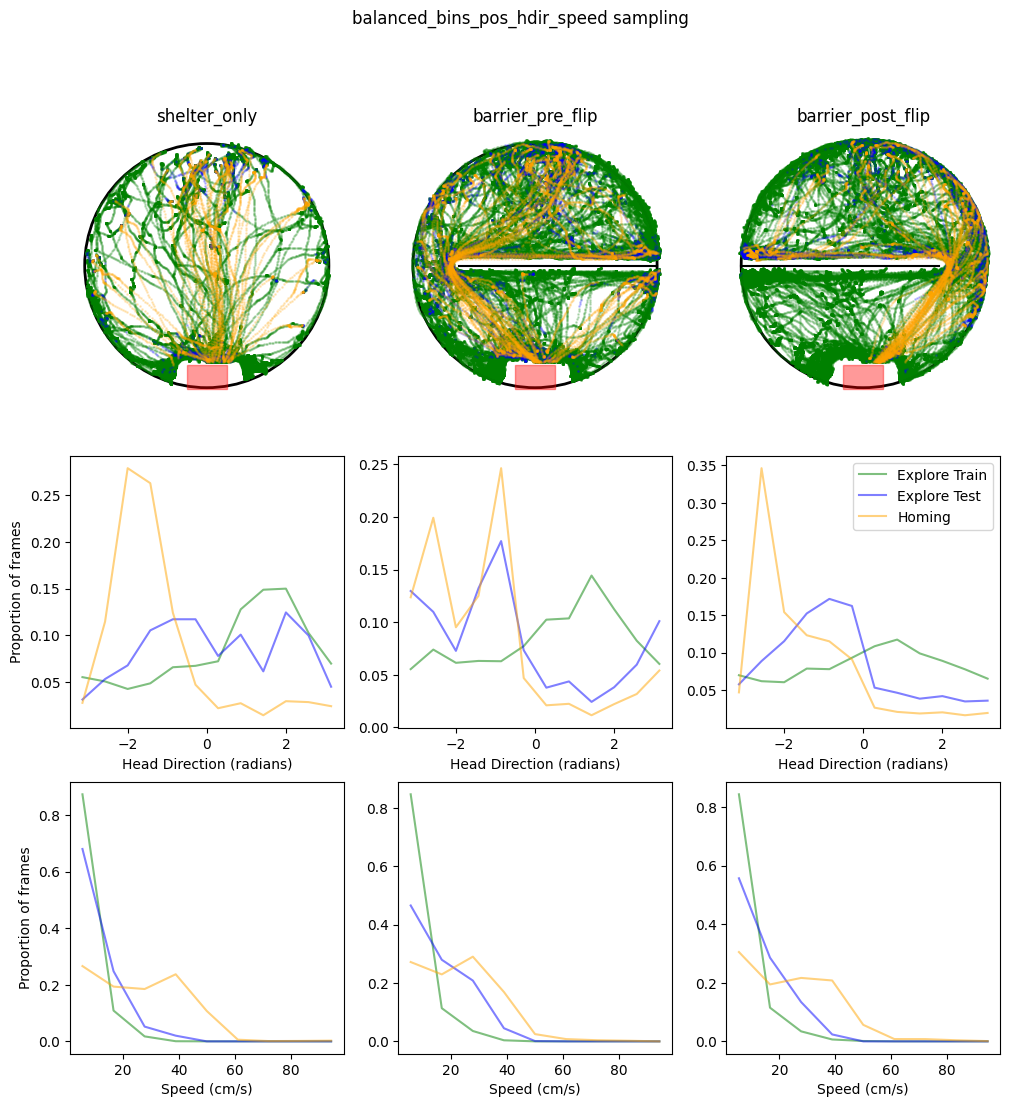

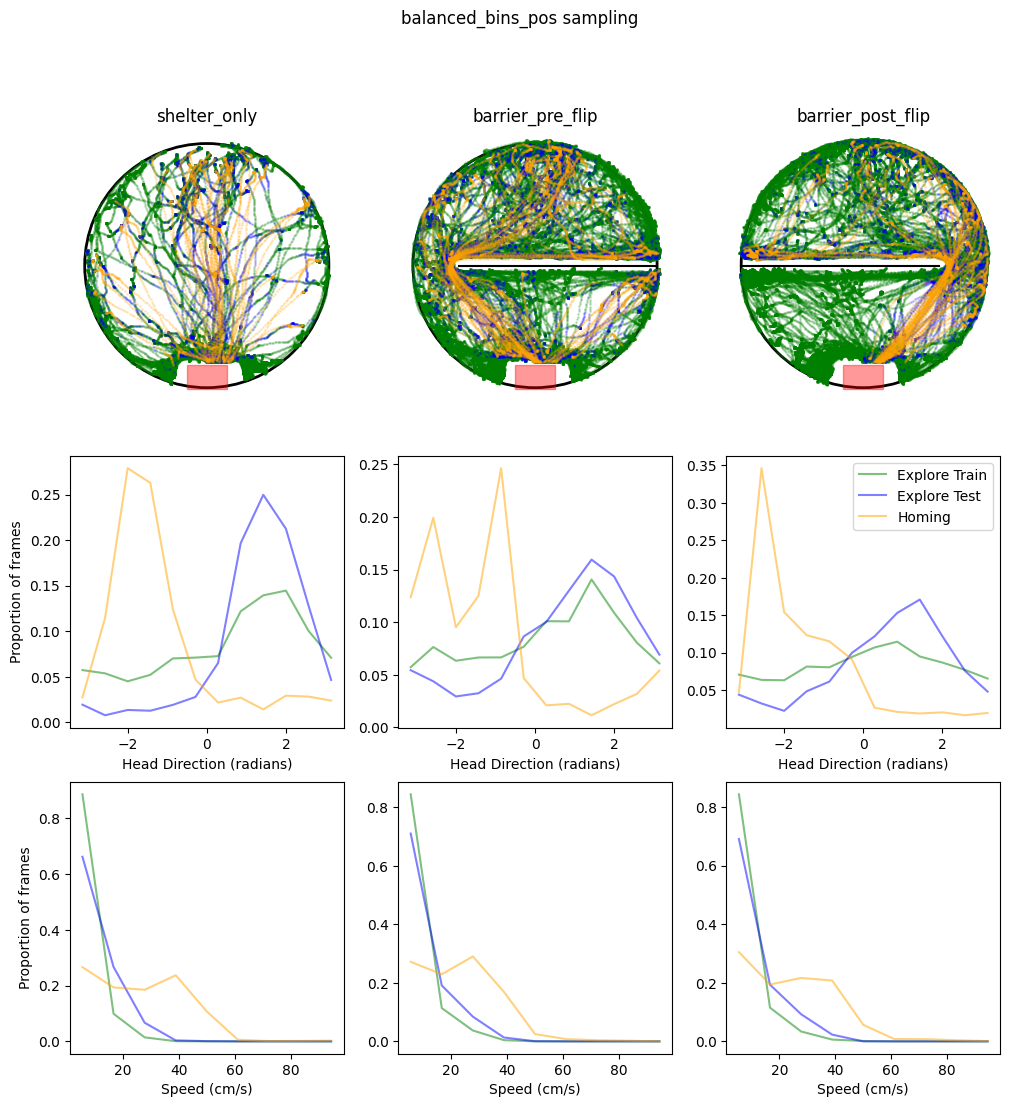

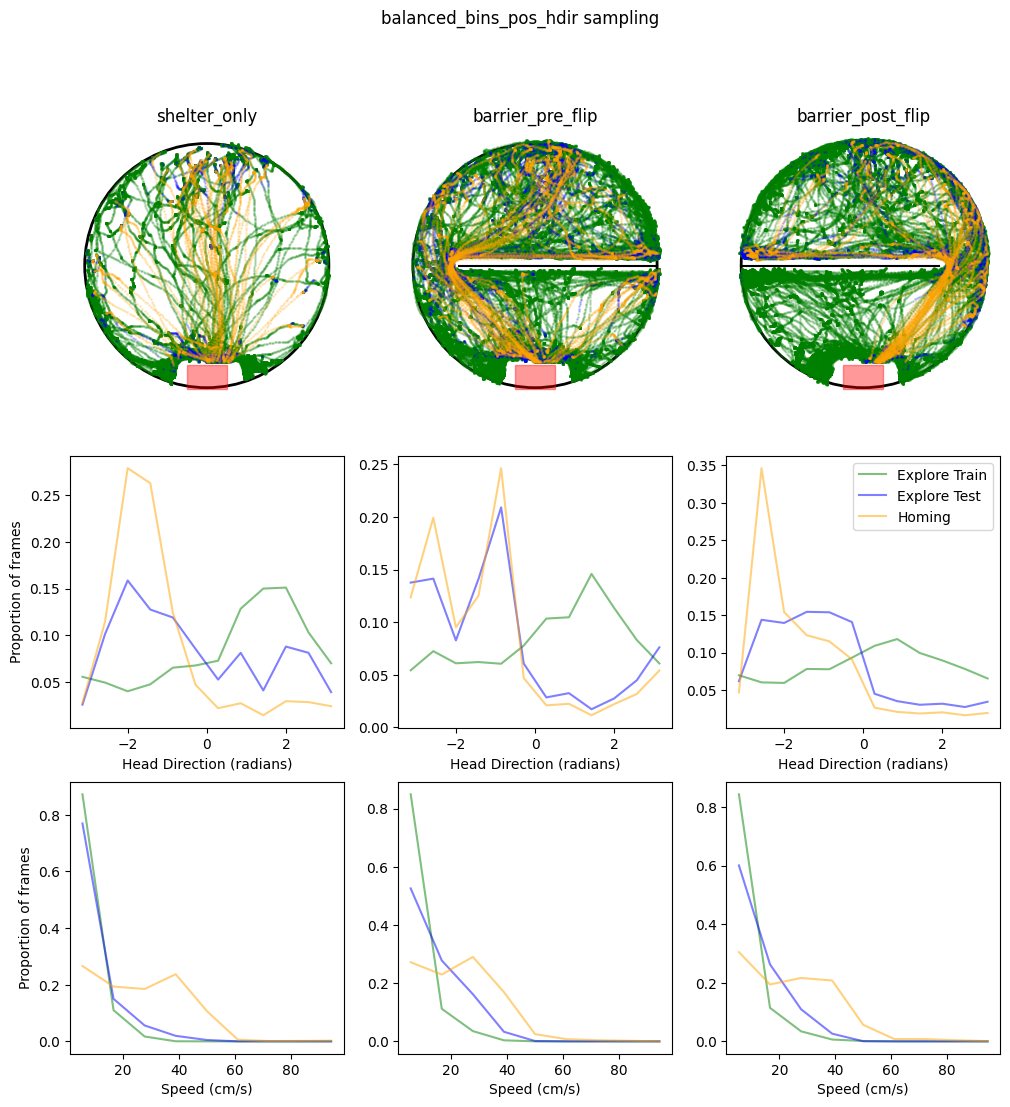

In [68]:
"""Visualize how different matching methods affect behavioral subsampling"""
Y, col_names = preprocess_behavioral_data(video_df, COLUMNS_TO_KEEP)
for method in ["balanced_bins_pos_hdir_speed", "balanced_bins_pos", "balanced_bins_pos_hdir"]:
    fig, axs = plt.subplots(3,3, figsize=(12,12))
    for c, cond in enumerate(cond_list):
        explore_train_idx, explore_test_idx, homing_indices = select_train_test_frames(video_df, cond, method = method)

        Arena(ax=axs[0,c], condition=cond, barrier_coordinates=session.barrier_location[:-1])
        axs[0,c].scatter(Y[explore_train_idx,np.where(col_names == "mouse_x_position")[0]], Y[explore_train_idx,np.where(col_names == "mouse_y_position")[0]], s=1, alpha = 0.2, label="Explore Train", color = "green")
        axs[0,c].scatter(Y[explore_test_idx,np.where(col_names == "mouse_x_position")[0]], Y[explore_test_idx,np.where(col_names == "mouse_y_position")[0]], s=1, alpha = 0.2, label="Explore Test", color = "blue")
        axs[0,c].scatter(Y[homing_indices,np.where(col_names == "mouse_x_position")[0]], Y[homing_indices,np.where(col_names == "mouse_y_position")[0]], s=1, alpha = 0.2, label="Homing", color = "orange")
        axs[0,c].set_title(f"{cond}")

        hdir = video_df["hdir"].to_numpy()
        h, _ = np.histogram(hdir[explore_train_idx], bins=np.linspace(-np.pi, np.pi, 13))
        axs[1,c].plot(np.linspace(-np.pi, np.pi, 12), h/np.sum(h), alpha=0.5, label="Explore Train", color = "green")
        h, _ = np.histogram(hdir[explore_test_idx], bins=np.linspace(-np.pi, np.pi, 13))
        axs[1,c].plot(np.linspace(-np.pi, np.pi, 12), h/np.sum(h), alpha=0.5, label="Explore Test", color = "blue")
        h, _ = np.histogram(hdir[homing_indices], bins=np.linspace(-np.pi, np.pi, 13))
        axs[1,c].plot(np.linspace(-np.pi, np.pi, 12), h/np.sum(h), alpha=0.5, label="Homing", color = "orange")
        axs[1,c].set_xlabel("Head Direction (radians)")
        if c == 0:
            axs[1,c].set_ylabel("Proportion of frames")
        if c == 2:
            axs[1,c].legend(loc="upper right")

        speed = video_df["speed"].to_numpy()
        bin_edges = np.linspace(0, 100, 10)
        h, _ = np.histogram(speed[explore_train_idx], bins=bin_edges)
        axs[2,c].plot(bin_edges[:-1]+np.diff(bin_edges)/2, h/np.sum(h), alpha=0.5, label="Explore Train", color = "green")
        h, _ = np.histogram(speed[explore_test_idx], bins=bin_edges)
        axs[2,c].plot(bin_edges[:-1]+np.diff(bin_edges)/2, h/np.sum(h), alpha=0.5, label="Explore Test", color = "blue")
        h, _ = np.histogram(speed[homing_indices], bins=bin_edges)
        axs[2,c].plot(bin_edges[:-1]+np.diff(bin_edges)/2, h/np.sum(h), alpha=0.5, label="Homing", color = "orange")
        axs[2,c].set_xlabel("Speed (cm/s)")
        if c == 0:
            axs[2,c].set_ylabel("Proportion of frames")
    plt.suptitle(f"{method} sampling")

In [65]:
COLUMNS_TO_KEEP = ["hdir", "hdir_velocity", "hdir_velocity", "mouse_x_position", "mouse_y_position", "speed", "acceleration", "hsa", "h_preflipbar_a", "h_postflipbar_a", "distance_to_shelter", "distance_to_barrier1", "distance_to_barrier2"]
# COLUMNS_TO_KEEP = ["speed", "acceleration"]

Y, col_names = preprocess_behavioral_data(video_df, COLUMNS_TO_KEEP)

n_components = min(5, len(COLUMNS_TO_KEEP)) # number of CCA components can't be more than number of behavior variables
train_explore = {'test_canonical_corr': np.full((3, n_components), np.nan), 
                 'train_canonical_corr': np.full((3, n_components), np.nan), 
                 'homing_canonical_corr': np.full((3, n_components), np.nan)}
train_homing = {'exp_match_canonical_corr': np.full((3, n_components), np.nan), 
                 'test_exp_canonical_corr': np.full((3, n_components), np.nan), 
                 'train_h_canonical_corr': np.full((3, n_components), np.nan)}

train_explore["X_train_loadings"] = {session_name:np.full((3, fcm.shape[1], n_components), np.nan)}
train_explore["X_test_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}
train_explore["X_homing_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}
train_homing["exp_match_X_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}
train_homing["test_exp_X_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}
train_homing["train_h_X_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}

for c, cond in enumerate(cond_list):

    explore_train_idx, explore_test_idx, homing_indices = select_train_test_frames(video_df, cond, method = "balanced_bins_pos")
    # check that indices don't fall below the session start time
    explore_train_idx = [idx for idx in explore_train_idx if idx >= session_start]
    explore_test_idx = [idx for idx in explore_test_idx if idx >= session_start]
    homing_indices = [idx for idx in homing_indices if idx >= session_start]

    # FIRST WE TRAIN ON EXPLORE, TEST ON HOMING
    A_X_train = fcm_z[explore_train_idx, :]
    A_Y_train = Y[explore_train_idx, :]
    A_X_test = fcm_z[explore_test_idx, :]
    A_Y_test = Y[explore_test_idx, :]
    B_X_test = fcm_z[homing_indices, :]
    B_Y_test = Y[homing_indices, :]

    # Assuming X_train is (time, neurons) and Y_train is (time, behaviors)
    # 1. Initialize CCA (n_components is the number of correlated pairs to find)
    cca = CCA(n_components=n_components)

    # 2. Fit the model (find the loading vectors)
    cca.fit(A_X_train, A_Y_train)

    # 3. Project the TRAINING data onto the loading vectors
    # X_c and Y_c are the "Canonical Scores"
    X_c, Y_c = cca.transform(A_X_train, A_Y_train)

    # 4. Project the TEST data (using the same weights found during training)
    A_X_test_c, A_Y_test_c = cca.transform(A_X_test, A_Y_test)
    B_X_test_c, B_Y_test_c = cca.transform(B_X_test, B_Y_test)

    # get the canonical correlation
    for i in range(n_components):
        train_explore['test_canonical_corr'][c, i] = safe_corrcoef(A_X_test_c[:,i], A_Y_test_c[:,i])
        train_explore['train_canonical_corr'][c, i] = safe_corrcoef(X_c[:,i], Y_c[:,i])
        train_explore['homing_canonical_corr'][c, i] = safe_corrcoef(B_X_test_c[:,i], B_Y_test_c[:,i])

    # get the loadings for the neurons
    train_explore['X_train_loadings'][session_name][c, :, :] = cca.x_loadings_
    train_explore['X_test_loadings'][session_name][c, :, :] = get_correlation_loadings(A_X_test, A_X_test_c)
    train_explore['X_homing_loadings'][session_name][c, :, :] = get_correlation_loadings(B_X_test, B_X_test_c)

    # SECOND WE TRAIN ON HOMING, TEST ON EXPLORE
    A_X_train = fcm_z[homing_indices, :]
    A_Y_train = Y[homing_indices, :]
    A_X_test = fcm_z[explore_test_idx, :]
    A_Y_test = Y[explore_test_idx, :]
    B_X_test = fcm_z[explore_train_idx, :]
    B_Y_test = Y[explore_train_idx, :]

    # Assuming X_train is (time, neurons) and Y_train is (time, behaviors)
    # 1. Initialize CCA (n_components is the number of correlated pairs to find)
    cca = CCA(n_components=n_components)

    # 2. Fit the model (find the loading vectors)
    cca.fit(A_X_train, A_Y_train)

    # 3. Project the TRAINING data onto the loading vectors
    # X_c and Y_c are the "Canonical Scores"
    X_c, Y_c = cca.transform(A_X_train, A_Y_train)

    # 4. Project the TEST data (using the same weights found during training)
    A_X_test_c, A_Y_test_c = cca.transform(A_X_test, A_Y_test)
    B_X_test_c, B_Y_test_c = cca.transform(B_X_test, B_Y_test)

    # get the canonical correlation
    for i in range(n_components):
        train_homing['exp_match_canonical_corr'][c, i] = safe_corrcoef(A_X_test_c[:,i], A_Y_test_c[:,i])
        train_homing['train_h_canonical_corr'][c, i] = safe_corrcoef(X_c[:,i], Y_c[:,i])
        train_homing['test_exp_canonical_corr'][c, i] = safe_corrcoef(B_X_test_c[:,i], B_Y_test_c[:,i])

    # get the loadings for the neurons
    train_homing['train_h_X_loadings'][session_name][c, :, :] = cca.x_loadings_
    train_homing['exp_match_X_loadings'][session_name][c, :, :] = get_correlation_loadings(A_X_test, A_X_test_c)
    train_homing['test_exp_X_loadings'][session_name][c, :, :] = get_correlation_loadings(B_X_test, B_X_test_c)

Text(0, 0.5, 'Correlation')

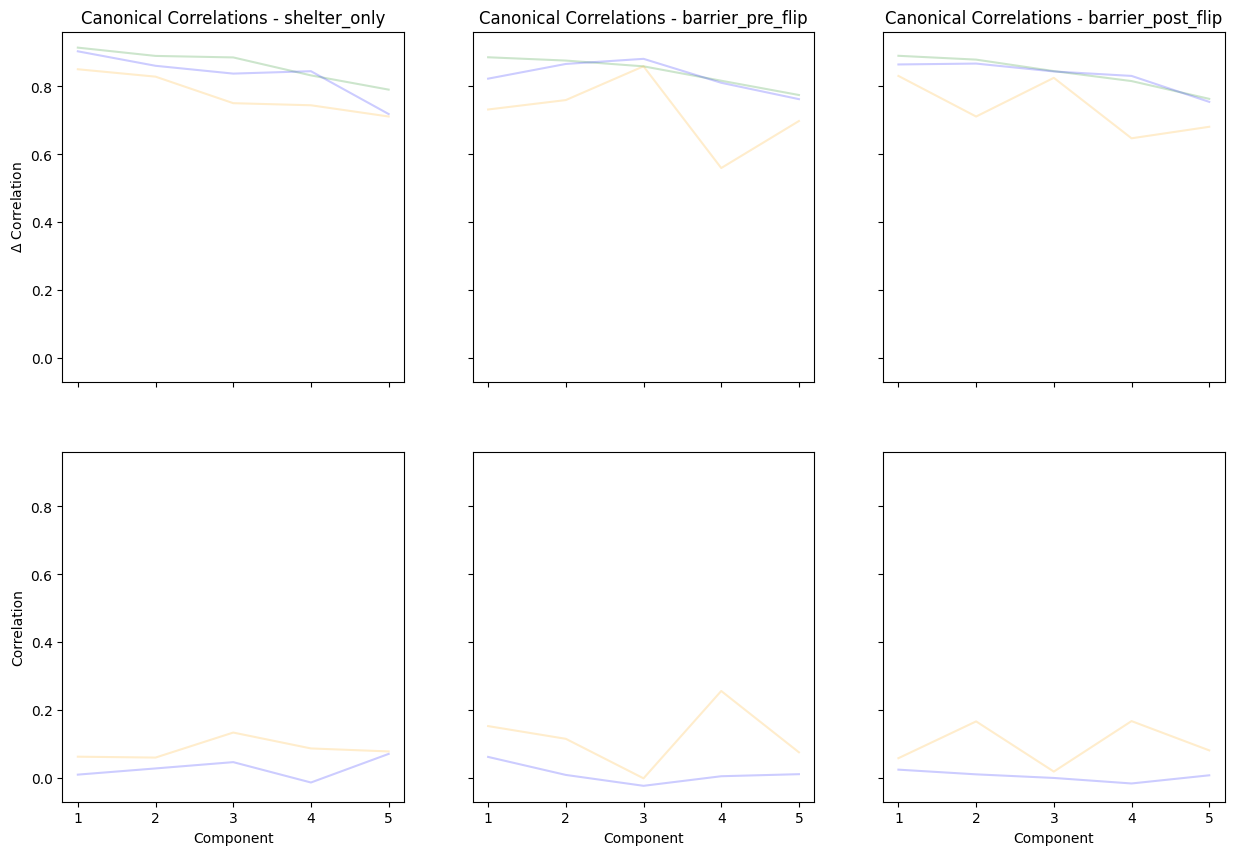

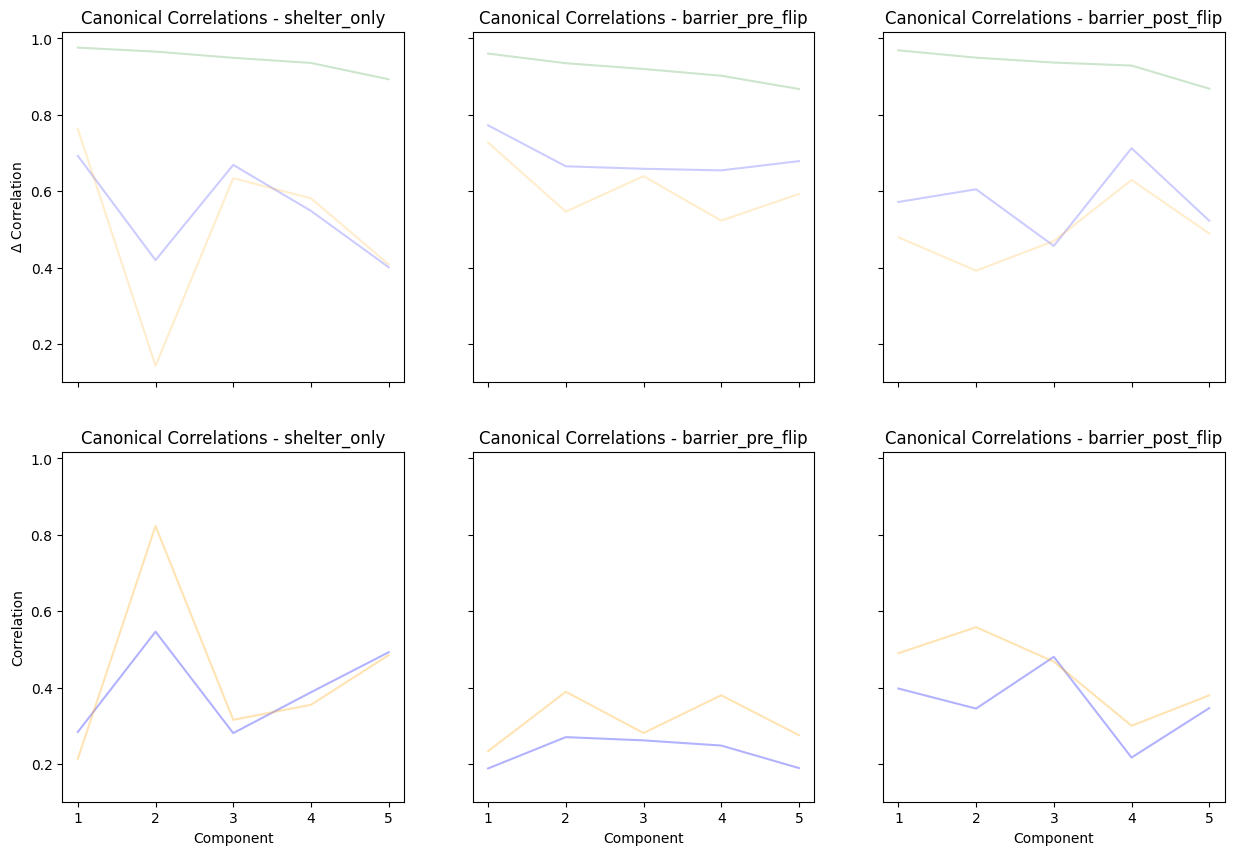

In [66]:
"""Visualize the canonical correlations for train explore vs test homing for each condition"""
fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
for c in range(len(cond_list)):
    axs[0,c].plot(train_explore['train_canonical_corr'][c, :], color = 'green', alpha = 0.2)
    axs[0,c].plot(train_explore['test_canonical_corr'][c, :], color = 'blue', alpha = 0.2)
    axs[0,c].plot(train_explore['homing_canonical_corr'][c, :], color = 'orange', alpha = 0.2)
    axs[0,c].set_title(f"Canonical Correlations - {cond_list[c]}")
    axs[0,c].set_xticks(range(n_components))
    axs[0,c].set_xticklabels(range(1, n_components+1))
    axs[1,c].plot(train_explore['train_canonical_corr'][c, :] - train_explore['test_canonical_corr'][c, :], color = 'blue', alpha = 0.2)
    axs[1,c].plot(train_explore['train_canonical_corr'][c, :] - train_explore['homing_canonical_corr'][c, :], color = 'orange', alpha = 0.2)
    axs[1,c].set_xticks(range(n_components))
    axs[1,c].set_xticklabels(range(1, n_components+1))
    axs[1,c].set_xlabel("Component")
axs[0,0].set_ylabel(r"$\Delta$ Correlation")
axs[1,0].set_ylabel("Correlation")

"""Visualize the canonical correlations for train homing vs test explore for each condition"""

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
for c in range(3):
    axs[0,c].plot(train_homing['train_h_canonical_corr'][c, :], color = 'green', alpha = 0.2)
    axs[0,c].plot(train_homing['exp_match_canonical_corr'][c, :], color = 'blue', alpha = 0.2)
    axs[0,c].plot(train_homing['test_exp_canonical_corr'][c, :], color = 'orange', alpha = 0.2)
    axs[0,c].set_title(f"Canonical Correlations - {cond_list[c]}")
    axs[0,c].set_xticks(range(n_components))
    axs[0,c].set_xticklabels(range(1, n_components+1))
    axs[1,c].plot(train_homing['train_h_canonical_corr'][c, :] - train_homing['exp_match_canonical_corr'][c, :], color = 'blue', alpha=0.3)
    axs[1,c].plot(train_homing['train_h_canonical_corr'][c, :] - train_homing['test_exp_canonical_corr'][c, :], color = 'orange', alpha = 0.3)
    axs[1,c].set_title(f"Canonical Correlations - {cond_list[c]}")
    axs[1,c].set_xticks(range(n_components))
    axs[1,c].set_xticklabels(range(1, n_components+1))
    axs[1,c].set_xlabel("Component")
axs[0,0].set_ylabel(r"$\Delta$ Correlation")
axs[1,0].set_ylabel("Correlation")